<a href="https://colab.research.google.com/github/spbromberg/Project-1-Group-5-DS-4002/blob/main/IMDb_Reviews_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
#load dataset

imdb = pd.read_csv("imdb_reviews.csv", nrows=10)
print(imdb)

   review_id                                             review  rating  \
0          0  Once again Mr. Costner has dragged out a movie...       2   
1          1  This is a pale imitation of 'Officer and a Gen...       3   
2          2  It seems ever since 1982, about every two or t...       3   
3          3  Wow, another Kevin Costner hero movie. Postman...       4   
4          4  Alas, another Costner movie that was an hour t...       4   
5          5  I wish I knew what to make of a movie like thi...       4   
6          6  A tough sell: British playwright Ronald Harwoo...       3   
7          7  Blake Edwards' legendary fiasco, begins to see...       1   
8          8  I'm not a big fan of musicals, although this t...       2   
9          9  David Bryce's comments nearby are exceptionall...       4   

  sentiment split  
0  negative  test  
1  negative  test  
2  negative  test  
3  negative  test  
4  negative  test  
5  negative  test  
6  negative  test  
7  negative  t

In [ ]:
#clean dataset

# Load dataset
imdb = pd.read_csv("imdb_reviews.csv")

# Function to clean each review
def clean_review(text):
    text = str(text).lower()                 # Make everything lowercase
    text = re.sub(r"<br\s*/?>", " ", text)  # Remove <br /> tags
    text = re.sub(r"<[^>]+>", " ", text)     # Remove any other HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)    # Remove numbers/punctuation/special characters
    text = re.sub(r"\s+", " ", text)         # Remove extra spaces
    return text.strip()

# Clean the review column
imdb["review_clean"] = imdb["review"].apply(clean_review)

# Look at original vs. cleaned reviews
print(imdb[["review", "review_clean"]].head())

                                              review  \
0  Once again Mr. Costner has dragged out a movie...   
1  This is a pale imitation of 'Officer and a Gen...   
2  It seems ever since 1982, about every two or t...   
3  Wow, another Kevin Costner hero movie. Postman...   
4  Alas, another Costner movie that was an hour t...   

                                        review_clean  
0  once again mr costner has dragged out a movie ...  
1  this is a pale imitation of officer and a gent...  
2  it seems ever since about every two or three y...  
3  wow another kevin costner hero movie postman t...  
4  alas another costner movie that was an hour to...  


The dataset is cleaned at this point.

In [ ]:
# Data validation check

print("Data Quality")
print("Total reviews: " + str(len(imdb)))
print("Missing values in review_clean: " + str(imdb['review_clean'].isna().sum()))
print("Duplicate reviews: " + str(imdb['review_clean'].duplicated().sum()))

print("\nClass balance check:")
print(imdb['sentiment'].value_counts())

print("\nTrain/test split check:")
print(imdb['split'].value_counts())

print("\nSample cleaned review:")
print(imdb['review_clean'].iloc[0])
print("Word count: " + str(len(imdb['review_clean'].iloc[0].split())))

Data Quality
Total reviews: 50000
Missing values in review_clean: 0
Duplicate reviews: 424

Class balance check:
sentiment
negative    25000
positive    25000
Name: count, dtype: int64

Train/test split check:
split
test     25000
train    25000
Name: count, dtype: int64

Sample cleaned review:
once again mr costner has dragged out a movie for far longer than necessary aside from the terrific sea rescue sequences of which there are very few i just did not care about any of the characters most of us have ghosts in the closet and costner s character are realized early on and then forgotten until much later by which time i did not care the character we should really care about is a very cocky overconfident ashton kutcher the problem is he comes off as kid who thinks he s better than anyone else around him and shows no signs of a cluttered closet his only obstacle appears to be winning over costner finally when we are well past the half way point of this stinker costner tells us all about 

Dataset checker. Ensures all data is acquired and processed correctly.

In [ ]:
# Create Text Features
# Word Count vs TF-IDF Setup

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Separate training and testing data based on the split column
X_train_text = imdb[imdb['split'] == 'train']['review_clean']
X_test_text = imdb[imdb['split'] == 'test']['review_clean']
y_train = imdb[imdb['split'] == 'train']['sentiment'].map({'positive': 1, 'negative': 0})
y_test = imdb[imdb['split'] == 'test']['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Training set size: {len(X_train_text)}")
print(f"Testing set size: {len(X_test_text)}")
print(f"Class balance in training: {y_train.value_counts()}")

Training set size: 25000
Testing set size: 25000
Class balance in training: sentiment
0    12500
1    12500
Name: count, dtype: int64


This separates the reviews into 25,000 training reviews and 25,000 testing reviews, then labels negative reviews as 0 and positive reviews as 1. The training data is evenly balanced, with 12,500 negative and 12,500 positive reviews.

In [ ]:
# Approach 1: Word Count

# CountVectorizer: How many times does each word appear in each review?
# min_df=5: word must appear in at least 5 documents
# max_df=0.8: word must appear in no more than 80% of documents (removes very common words)

count_vectorizer = CountVectorizer(
    max_features=5000,  # Keep only the top 5000 most frequent words
    min_df=5,           # Word must appear in at least 5 reviews
    max_df=0.8,         # Word can appear in at most 80% of reviews
    stop_words='english' # Remove common English words like 'the', 'a', etc.
)

# Fit on training data only (never fit on test data!)
X_train_count = count_vectorizer.fit_transform(X_train_text)
X_test_count = count_vectorizer.transform(X_test_text)

print("Word Count approach - Feature matrix shape: +",  X_train_count.shape)
print("Number of features created: +", X_train_count.shape[1])

# Quick example: what are some of the words it found?
feature_names_count = count_vectorizer.get_feature_names_out()
print("Sample words: +", feature_names_count[:20])

Word Count approach - Feature matrix shape: + (25000, 5000)
Number of features created: + 5000
Sample words: + ['abandoned' 'abc' 'abilities' 'ability' 'able' 'abraham' 'absence'
 'absent' 'absolute' 'absolutely' 'absurd' 'absurdity' 'abuse' 'abused'
 'abusive' 'abysmal' 'academy' 'accent' 'accents' 'accept']


This turns each review into word counts, using up to 5,000 useful words while removing words that are too rare or too common. The output shows that the 25,000 training reviews are now represented by 5,000 word features.

In [ ]:
# Approach 2: TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Remove common stop words, but KEEP important negation words
custom_stop_words = list(
    ENGLISH_STOP_WORDS - {"not", "no", "never"}
)

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    stop_words=custom_stop_words
)

# Fit ONLY on training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

# Transform test data using the already-fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (25000, 5000)
Testing shape: (25000, 5000)


This uses TF-IDF to give more importance to useful words and less importance to very common words, while keeping important words like “not,” “no,” and “never.” TF-IDF measures how important a word is to a review based on how often it appears in that review compared to how common it is across all reviews. The output shows that both the training and testing sets have 25,000 reviews represented by 5,000 word features.

In [ ]:
# Compare Word Count vs TF-IDF

# Train a logistic regression model with each approach and compare
# using 5-fold cross-validation on the training data

lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 5-fold CV with Word Count features
cv_scores_count = cross_val_score(
    lr_model, X_train_count, y_train,
    cv=5, scoring='accuracy'
)

# 5-fold CV with TF-IDF features
cv_scores_tfidf = cross_val_score(
    lr_model, X_train_tfidf, y_train,
    cv=5, scoring='accuracy'
)

print("Word Count approach - 5-fold CV Accuracy:")
print(f"  Scores: {cv_scores_count}")
print(f"  Mean: {cv_scores_count.mean():.4f} (+/- {cv_scores_count.std():.4f})")

print("\nTF-IDF approach - 5-fold CV Accuracy:")
print(f"  Scores: {cv_scores_tfidf}")
print(f"  Mean: {cv_scores_tfidf.mean():.4f} (+/- {cv_scores_tfidf.std():.4f})")

# Which one is better?
if cv_scores_tfidf.mean() > cv_scores_count.mean():
    print("\nTF-IDF performs better! We'll use TF-IDF for final model.")
    better_approach = "tfidf"
else:
    print("\nWord Count performs better! We'll use Word Count for final model.")
    better_approach = "count"

Word Count approach - 5-fold CV Accuracy:
  Scores: [0.814  0.8096 0.814  0.8246 0.8208]
  Mean: 0.8166 (+/- 0.0054)

TF-IDF approach - 5-fold CV Accuracy:
  Scores: [0.8602 0.8612 0.8574 0.8636 0.8588]
  Mean: 0.8602 (+/- 0.0021)

TF-IDF performs better! We'll use TF-IDF for final model.


This compares the Word Count and TF-IDF approaches using logistic regression and 5-fold cross-validation. The model is trained five different times so each part of the training data gets a chance to be used for validation. Word Count had an average accuracy of 81.66%, while TF-IDF had a higher average accuracy of 86.02%, so TF-IDF should be chosen for the final model.

In [ ]:
# Final Logistic Regression Model

from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(max_iter=1000, random_state=42)

# Train using all training data
final_model.fit(X_train_tfidf, y_train)

print("Final logistic regression model is trained.")

Final logistic regression model is trained.


This trains the final logistic regression model using all 25,000 training reviews and the TF-IDF features. The model learns which word patterns are associated with positive and negative reviews so it can later predict the sentiment of new reviews.

In [ ]:
# Predict sentiment for the test reviews

y_pred = final_model.predict(X_test_tfidf)

print("Number of predictions:", len(y_pred))
print("First 10 predictions:", y_pred[:10])       #checker to see if all works

Number of predictions: 25000
First 10 predictions: [0 0 0 1 0 1 1 0 1 1]


This uses the final model to predict whether each of the 25,000 test reviews is positive or negative. The output confirms that predictions were made for all test reviews, where 0 means negative and 1 means positive.

In [ ]:
# evaluate Final Model

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Final Test Results")
print("------------------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Final Test Results
------------------
Accuracy:  0.8795
Precision: 0.8772
Recall:    0.8826
F1 Score:  0.8799
Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



This evaluates how well the final model predicted the 25,000 test reviews using accuracy, precision, recall, and F1 score. The model achieved about 88% across all measures, meaning it correctly classified about 88% of the reviews and performed similarly for both positive and negative reviews.

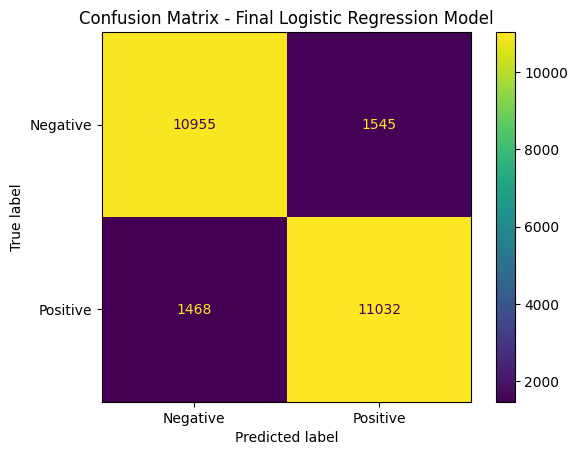

In [ ]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Negative", "Positive"])

plt.title("Confusion Matrix - Final Logistic Regression Model")
plt.show()

This confusion matrix shows how the model’s predictions compare to the actual review sentiment: it correctly classified 10,955 negative reviews and 11,032 positive reviews, while incorrectly classifying 1,545 negative and 1,468 positive reviews. This helps our project goal because it shows that the model can use language patterns to distinguish positive and negative reviews fairly accurately, while also showing exactly where the model makes mistakes.

In [ ]:
# Find Most Important Words

feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = final_model.coef_[0]

# Sort coefficients
sorted_indices = np.argsort(coefficients)

# 20 words most associated with negative reviews
negative_indices = sorted_indices[:20]

# 20 words most associated with positive reviews
positive_indices = sorted_indices[-20:][::-1]

print("Top 20 words associated with NEGATIVE reviews:")
for i in negative_indices:
    print(f"{feature_names[i]:20s} {coefficients[i]:.4f}")

print("\nTop 20 words associated with POSITIVE reviews:")
for i in positive_indices:
    print(f"{feature_names[i]:20s} {coefficients[i]:.4f}")

Top 20 words associated with NEGATIVE reviews:
worst                -8.9735
waste                -6.5244
awful                -6.4525
bad                  -6.3601
boring               -5.5918
poor                 -5.0593
worse                -4.6479
poorly               -4.5549
dull                 -4.4618
disappointment       -4.3935
terrible             -4.3627
unfortunately        -4.1768
no                   -4.1743
horrible             -4.1632
fails                -3.9150
disappointing        -3.8970
annoying             -3.8860
mess                 -3.8410
ridiculous           -3.7528
supposed             -3.6865

Top 20 words associated with POSITIVE reviews:
great                6.3194
excellent            5.9741
perfect              4.8369
best                 4.7186
wonderful            4.6118
favorite             4.1421
amazing              4.1311
today                3.6961
loved                3.6701
fun                  3.5137
brilliant            3.4150
enjoyed          

This finds the 20 words most strongly associated with negative reviews and the 20 words most strongly associated with positive reviews based on the logistic regression model. Words like “worst,” “waste,” and “awful” are strongly connected with negative reviews, while words like “great,” “excellent,” and “perfect” are strongly connected with positive reviews, which directly helps answer our research question about how language patterns differ between the two groups.

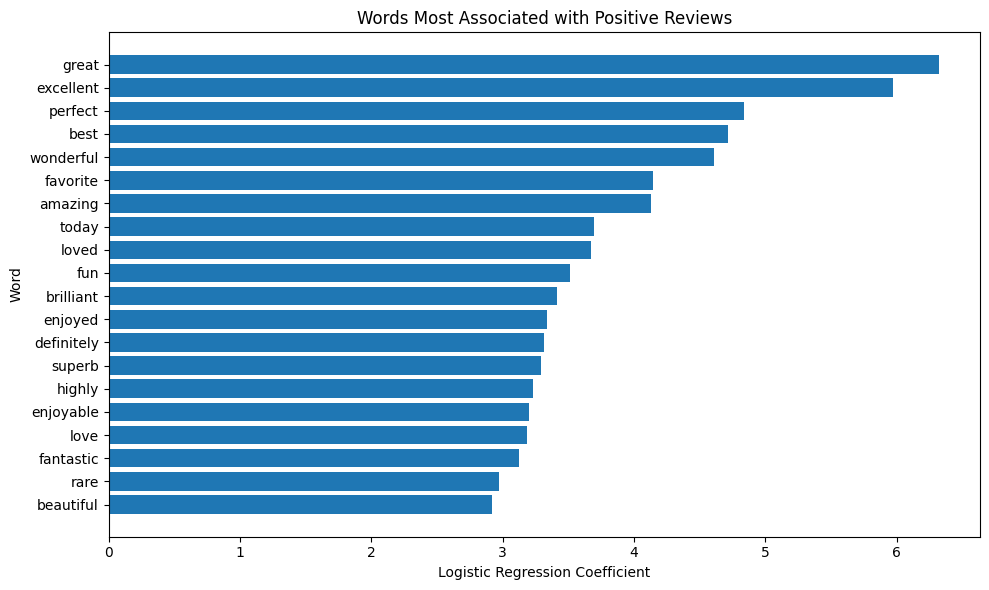

In [ ]:
# Top Positive Words

positive_words = feature_names[positive_indices]
positive_coef = coefficients[positive_indices]

plt.figure(figsize=(10, 6))
plt.barh(positive_words[::-1], positive_coef[::-1])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word")
plt.title("Words Most Associated with Positive Reviews")
plt.tight_layout()
plt.show()

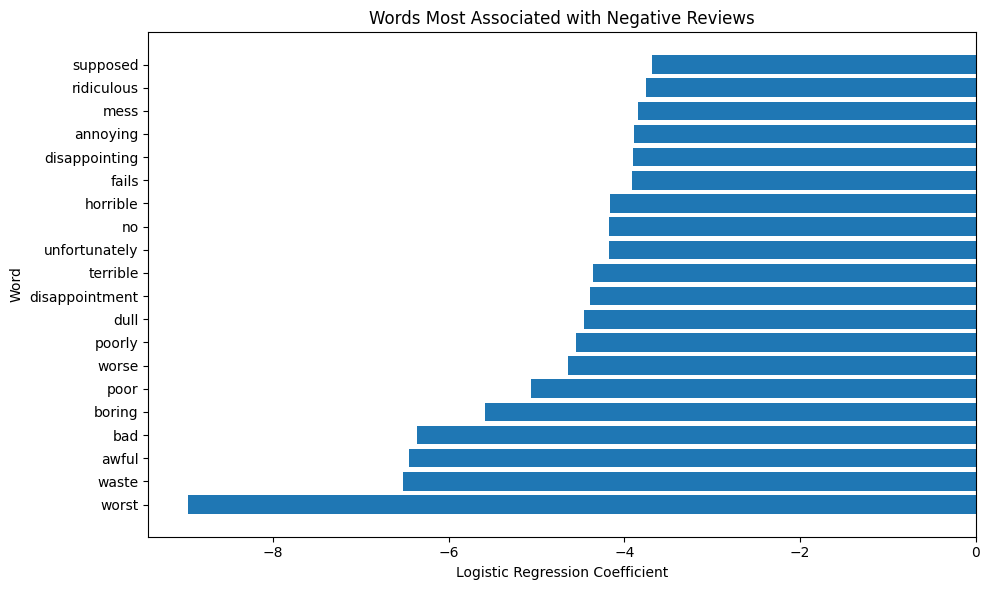

In [ ]:
# Top Negative Words

negative_words = feature_names[negative_indices]
negative_coef = coefficients[negative_indices]

plt.figure(figsize=(10, 6))
plt.barh(negative_words, negative_coef)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word")
plt.title("Words Most Associated with Negative Reviews")
plt.tight_layout()
plt.show()

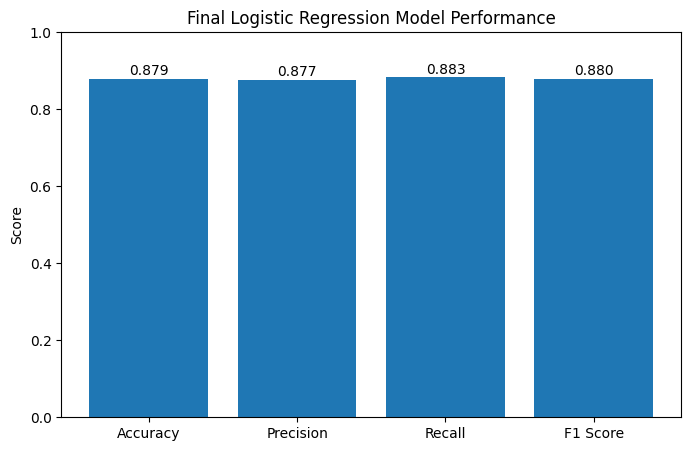

In [ ]:
# Final Model Performance

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Final Logistic Regression Model Performance")

for i, score in enumerate(scores):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

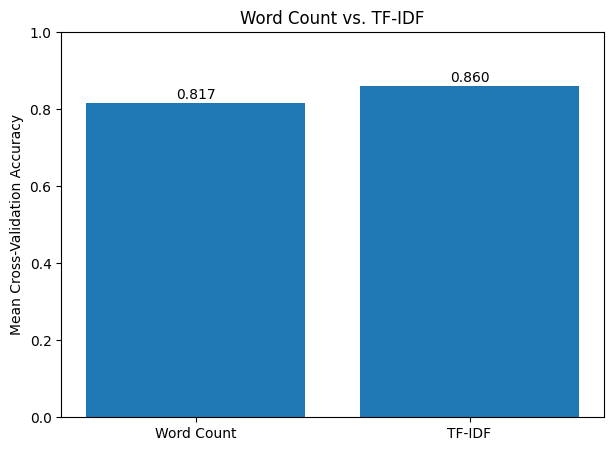

In [ ]:
#OPTIONAL

# Compare Feature Methods

methods = ["Word Count", "TF-IDF"]
cv_accuracy = [
    cv_scores_count.mean(),
    cv_scores_tfidf.mean()
]

plt.figure(figsize=(7, 5))
plt.bar(methods, cv_accuracy)

plt.ylim(0, 1)
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Word Count vs. TF-IDF")

for i, score in enumerate(cv_accuracy):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

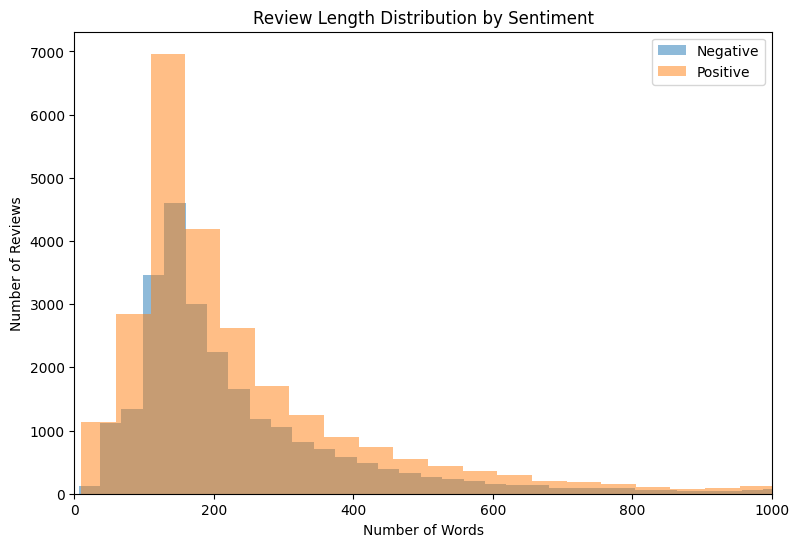

In [ ]:
# Review Length Distribution

plt.figure(figsize=(9, 6))

plt.hist(
    imdb[imdb["sentiment"] == "negative"]["word_count"],
    bins=50,
    alpha=0.5,
    label="Negative"
)

plt.hist(
    imdb[imdb["sentiment"] == "positive"]["word_count"],
    bins=50,
    alpha=0.5,
    label="Positive"
)

plt.xlim(0, 1000)
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Review Length Distribution by Sentiment")
plt.legend()
plt.show()

Summary

We used 50,000 IMDb reviews, split evenly into 25,000 training and 25,000 testing reviews, with an equal number of positive and negative reviews. After cleaning the text, we compared Word Count and TF-IDF using 5-fold cross-validation. Word Count had an average accuracy of 81.66%, while TF-IDF performed better at 86.02%, so we used TF-IDF for our final logistic regression model.

The final model was tested on the 25,000 unused test reviews and achieved 87.95% accuracy, 87.72% precision, 88.26% recall, and an F1 score of 87.99%. The model correctly classified 10,955 negative reviews and 11,032 positive reviews. This shows that the model performed similarly for both groups and exceeded our project goal of at least 85% accuracy.

The word analysis also showed clear differences in the language used between the two groups. Words like “great,” “excellent,” “perfect,” and “wonderful” were strongly associated with positive reviews, while words like “worst,” “waste,” “awful,” and “boring” were strongly associated with negative reviews. Overall, our results show that word choice contains useful language patterns for distinguishing positive and negative IMDb reviews, even without using the movie rating.
